In [1]:
import sqlite3
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

In [2]:
def get_table_names():
    conn = sqlite3.connect('seed.sqlite')
    cursor = conn.cursor()

    cursor.execute('SELECT name FROM sqlite_master WHERE type="table"')
    results = cursor.fetchall()

    print('table results:', results)

    for table in results:
        table_name = table[0]
        cursor.execute(f'SELECT * FROM {table_name}')
        cols = [desc[0] for desc in cursor.description]
        print(f'\nTable: {table_name}')
        print('Columns:', cols)

    conn.close()
    return

def get_titles(date = '2026-07-20'):
    conn = sqlite3.connect('seed.sqlite')
    cursor = conn.cursor()

    cursor.execute(f'SELECT title, feed_source  FROM items WHERE date(published_at) = "{date}"')
    results = cursor.fetchall()

    conn.close

    return results

In [7]:
title_results = get_titles()

titles = [col[0] for col in title_results]
sources = [col[1] for col in title_results]

vectoriser = TfidfVectorizer(stop_words='english')
X = vectoriser.fit_transform(titles)

model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.65,
    metric='cosine',
    linkage='average'
)
labels = model.fit_predict(X.toarray())

# 3. group titles by their cluster label
clusters = defaultdict(list)
for title, src, label in zip(titles, sources, labels):
    clusters[label].append((title,src))

# 4. print only clusters with more than one title
for label, group in clusters.items():
    if len(group) > 1:
        print(f"\nCluster {label}:")
        for title, src in group:
            print(f"  - [{src}]{title}")


Cluster 94:
  - [guardian_science]Monday briefing: 50 years after Viking landed on Mars, did Nasa overlook evidence of life?
  - [the_atlantic]Photos: 50 Years Since Viking 1 Landed on Mars

Cluster 38:
  - [guardian_science]Can you solve it? Do you think like a physicist?
  - [guardian_science]Did you solve it? Do you think like a physicist?

Cluster 22:
  - [mit_technology_review]AI is more likely than humans to form biases when hiring
  - [mit_technology_review]The Download: AI hiring biases, and weather data sabotage

Cluster 5:
  - [gizmodo]How Much Coffee Is Too Much? Heart Experts Have a New Answer
  - [environmental_news_network]Coffee and Heart Health: How Many Cups of Caffeinated Coffee Are Safe to Drink Each Day?
  - [the_hill]Drinking 5 cups of coffee a day is safe and could reduce heart risk: Report

Cluster 0:
  - [the_guardian_-_world_news]Iran vows not a ‘single drop’ of oil or gas will pass strait of Hormuz as US carries out ninth night of strikes – Middle East crisis

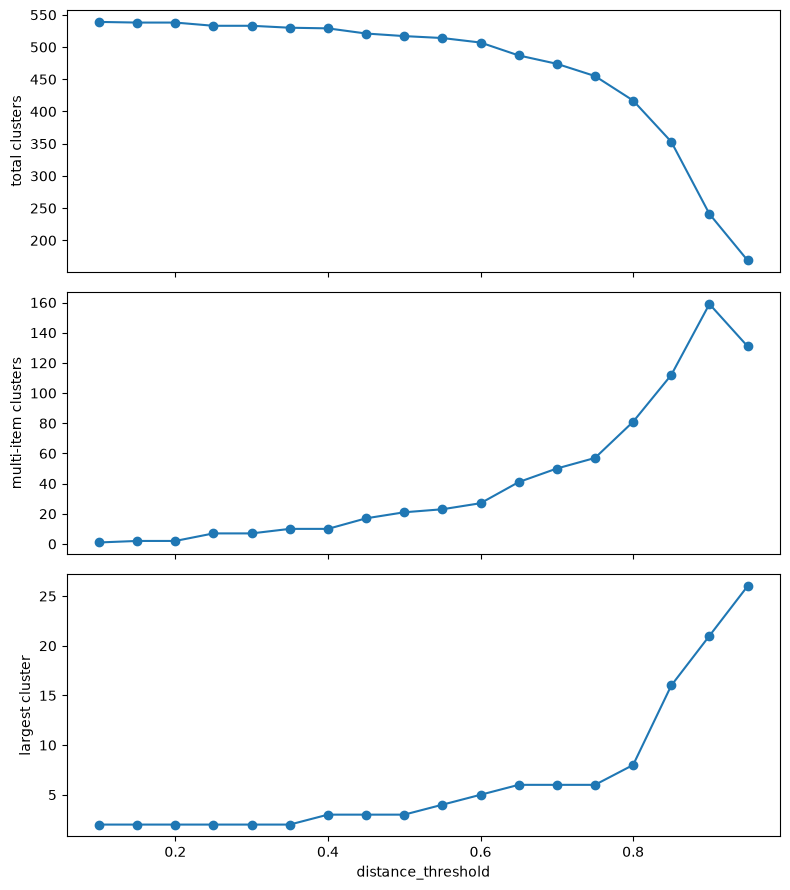

In [ ]:
# precompute the distance matrix ONCE, reuse for every threshold
D = cosine_distances(X.toarray())

thresholds = np.arange(0.1, 1.0, 0.05)
n_clusters = []
n_multi = []          # clusters with >1 item (actual merges)
largest = []          # size of biggest cluster (chaining detector)

for t in thresholds:
    model = AgglomerativeClustering(
        n_clusters=None, distance_threshold=t,
        metric="precomputed", linkage="average",
    )
    labels = model.fit_predict(D)
    sizes = np.bincount(labels)
    n_clusters.append(len(sizes))
    n_multi.append(int((sizes > 1).sum()))
    largest.append(int(sizes.max()))

fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(thresholds, n_clusters, marker="o"); ax[0].set_ylabel("total clusters")
ax[1].plot(thresholds, n_multi, marker="o");   ax[1].set_ylabel("multi-item clusters")
ax[2].plot(thresholds, largest, marker="o");   ax[2].set_ylabel("largest cluster")
ax[2].set_xlabel("distance_threshold")
plt.tight_layout(); plt.savefig("threshold_sweep.png", dpi=120)
